In [3]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/train_ml.csv"
test_url = "https://raw.githubusercontent.com/touXik/LLM-vs-ML-projet-nlp-/main/data/test_ml.csv"

In [1]:
!pip install xgboost -q

In [12]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

In [13]:
train = pd.read_csv(train_url)
test  = pd.read_csv(test_url)

X_train = train.drop("Outcome", axis=1)
y_train = train["Outcome"]

X_test = test.drop("Outcome", axis=1)
y_test = test["Outcome"]

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Classes train : {y_train.value_counts().to_dict()}")

Train : (800, 8)  |  Test : (154, 8)
Classes train : {0: 400, 1: 400}


In [14]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost":       XGBClassifier(n_estimators=100, random_state=42,
                                   eval_metric='logloss', verbosity=0)
}


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=== VALIDATION CROISÉE 5-FOLD ===\n")

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = scores
    print(f"{name}")
    print(f"  F1 par fold : {scores.round(3)}")
    print(f"  Moyenne : {scores.mean():.3f}  (+/- {scores.std():.3f})\n")

=== VALIDATION CROISÉE 5-FOLD ===

Random Forest
  F1 par fold : [0.792 0.824 0.829 0.821 0.847]
  Moyenne : 0.823  (+/- 0.018)

SVM
  F1 par fold : [0.768 0.798 0.807 0.807 0.752]
  Moyenne : 0.786  (+/- 0.022)

XGBoost
  F1 par fold : [0.782 0.812 0.805 0.802 0.826]
  Moyenne : 0.805  (+/- 0.014)



In [16]:
results = {}

for name, model in models.items():
    # Entraînement sur tout le train
    model.fit(X_train, y_train)

    # Prédictions
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Métriques
    results[name] = {
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred),
        "Recall"    : recall_score(y_test, y_pred),
        "F1"        : f1_score(y_test, y_pred),
        "AUC"       : roc_auc_score(y_test, y_pred_prob),
        "y_pred"    : y_pred,
        "y_prob"    : y_pred_prob
    }

# Affichage tableau
df_results = pd.DataFrame(results).T[["Accuracy", "Precision", "Recall", "F1", "AUC"]]
print("=== RÉSULTATS SUR LE TEST ===\n")
print(df_results.round(3))

=== RÉSULTATS SUR LE TEST ===

               Accuracy Precision    Recall        F1       AUC
Random Forest  0.733766       0.6  0.722222  0.655462    0.8075
SVM            0.707792  0.558442  0.796296  0.656489  0.786667
XGBoost        0.733766  0.606557  0.685185  0.643478  0.817407


/tmp/ipykernel_311/689461150.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,


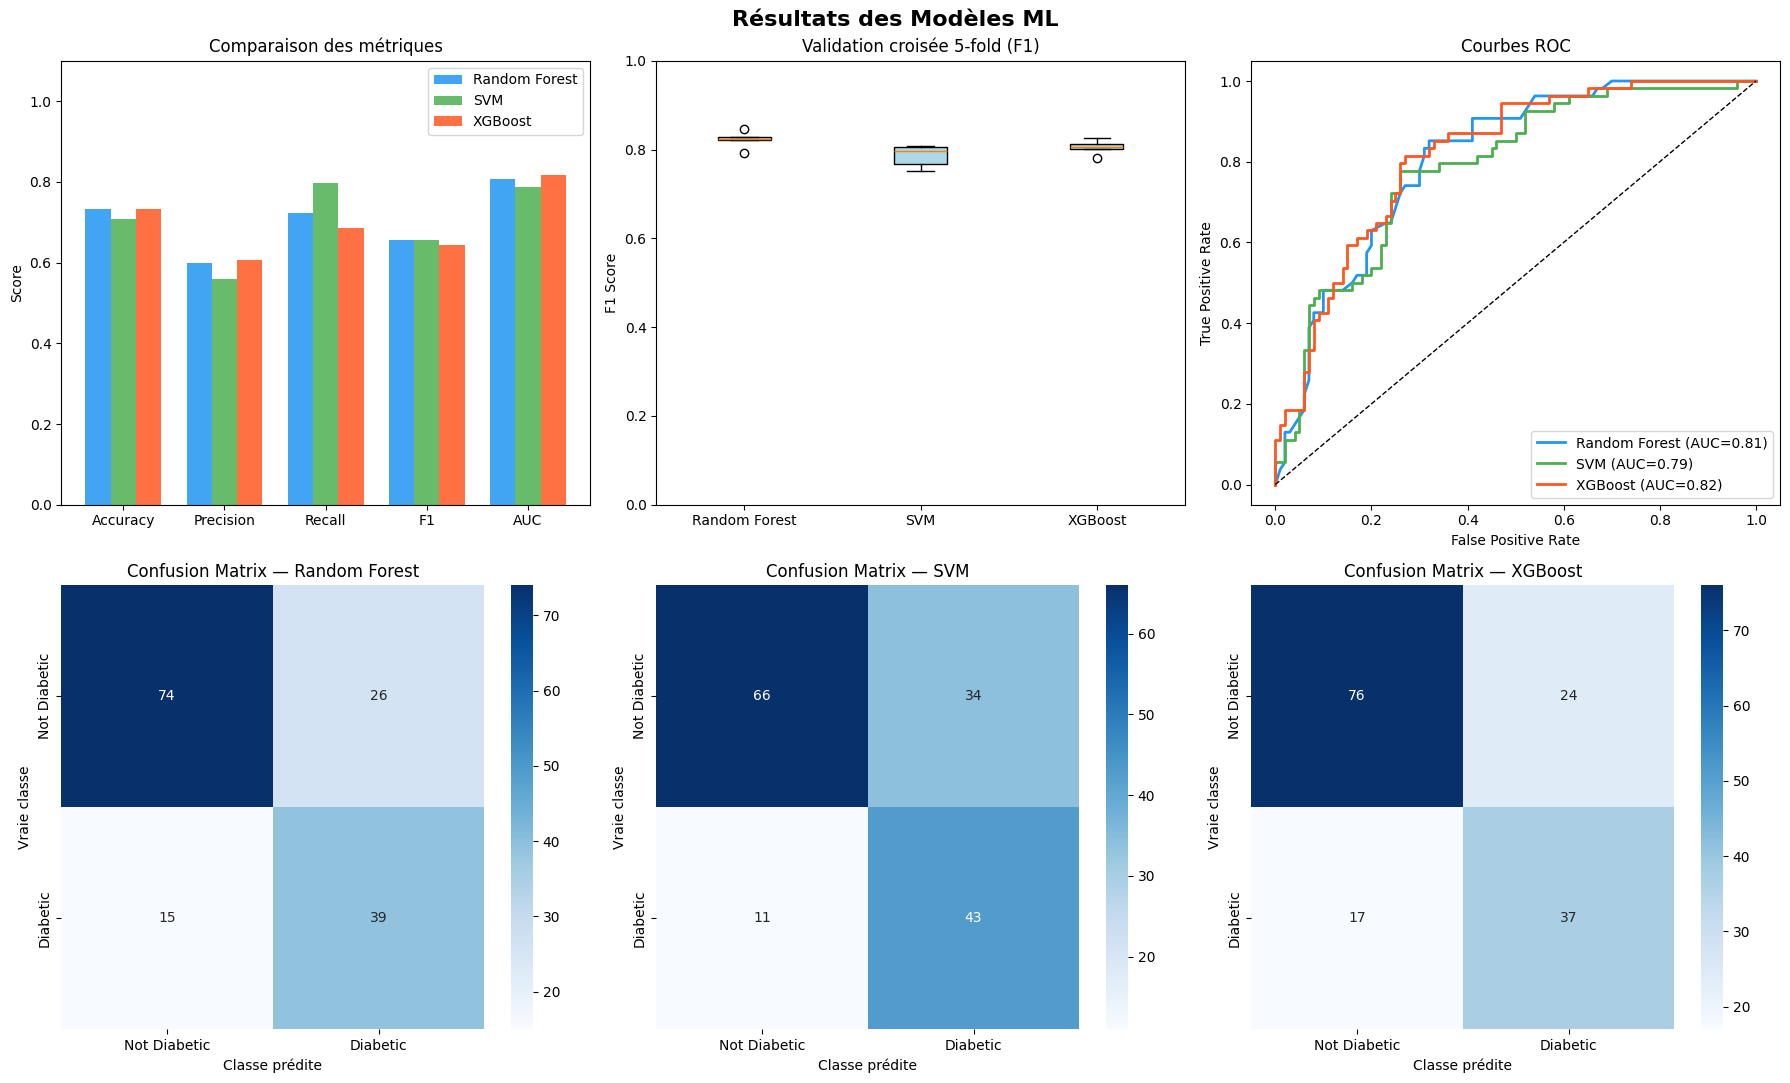

Graphique sauvegardé : resultats_ml.png


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Résultats des Modèles ML", fontsize=16, fontweight='bold')

# ── Graphique 1 : Comparaison des métriques ──
ax1 = axes[0, 0]
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
x = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    vals = [results[name][m] for m in metrics]
    ax1.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.set_title("Comparaison des métriques")
ax1.legend()
ax1.set_ylabel("Score")

# ── Graphique 2 : Validation croisée (boxplot) ──
ax2 = axes[0, 1]
ax2.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
ax2.set_title("Validation croisée 5-fold (F1)")
ax2.set_ylabel("F1 Score")
ax2.set_ylim(0, 1)

# ── Graphique 3 : Courbes ROC ──
ax3 = axes[0, 2]
for name, color in zip(results.keys(), colors):
    fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
    auc = results[name]["AUC"]
    ax3.plot(fpr, tpr, color=color, label=f"{name} (AUC={auc:.2f})", linewidth=2)
ax3.plot([0,1], [0,1], 'k--', linewidth=1)
ax3.set_title("Courbes ROC")
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend()

# ── Graphiques 4, 5, 6 : Matrices de confusion ──
for idx, (name, color) in enumerate(zip(results.keys(), colors)):
    ax = axes[1, idx]
    cm = confusion_matrix(y_test, results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=["Not Diabetic", "Diabetic"],
                yticklabels=["Not Diabetic", "Diabetic"])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_ylabel("Vraie classe")
    ax.set_xlabel("Classe prédite")

plt.tight_layout()
plt.savefig("resultats_ml.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé : resultats_ml.png")

In [18]:
print("=== RAPPORT DÉTAILLÉ PAR MODÈLE ===\n")

for name in results.keys():
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(
        y_test,
        results[name]["y_pred"],
        target_names=["Not Diabetic", "Diabetic"]
    ))

=== RAPPORT DÉTAILLÉ PAR MODÈLE ===

  Random Forest
              precision    recall  f1-score   support

Not Diabetic       0.83      0.74      0.78       100
    Diabetic       0.60      0.72      0.66        54

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

  SVM
              precision    recall  f1-score   support

Not Diabetic       0.86      0.66      0.75       100
    Diabetic       0.56      0.80      0.66        54

    accuracy                           0.71       154
   macro avg       0.71      0.73      0.70       154
weighted avg       0.75      0.71      0.71       154

  XGBoost
              precision    recall  f1-score   support

Not Diabetic       0.82      0.76      0.79       100
    Diabetic       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weigh